# 05 - V2 Feature Engineering

This notebook creates the modelling dataset for the Smart Buy Window Predictor price-drop model.

The cleaned V2 dataset was produced in: `notebooks/04_v2_data_cleaning.ipynb` using: `src/data/reprocess_raw.py`

The cleaned dataset is: `data/processed/clean_data_v2.csv`

The goal of this notebook is to create one row per product-date prediction point, with historical features available up to day `T` and a future label showing whether the selected price drops within the next 14 days.

The main prediction target is: `label_drop_14d`

This indicates whether the selected modelling price drops by at least a chosen percentage threshold at any point from `T+1` to `T+14`.

The output of this notebook will be saved as: `data/processed/features_v2.csv`

In [16]:
# Cell 2 - Import Libraries and Set Display Options

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)
pd.set_option("display.max_colwidth", 120)
pd.set_option("display.colheader_justify", "left")

In [17]:
# Cell 3 - Load the Cleaned V2 Dataset

CLEAN_PATH = Path("../data/processed/clean_data_v2.csv")
FEATURES_PATH = Path("../data/processed/features_v2.csv")

df = pd.read_csv(CLEAN_PATH)
df["date"] = pd.to_datetime(df["date"])

df = df.sort_values(["asin", "date"]).reset_index(drop=True)

print("Cleaned dataset shape:", df.shape)
print("Unique ASINs:", df["asin"].nunique())
print("Date range:", df["date"].min().date(), "to", df["date"].max().date())
print("Price range:", f"${df['amazon_price'].min():.2f}", "to", f"${df['amazon_price'].max():.2f}")

preview_cols = [
    "date",
    "asin",
    "amazon_price",
    "price_source",
    "new_price_shipping_included",
    "sales_rank",
    "offer_count",
    "root_category",
    "availability_amazon_label"
]

df[preview_cols].head()

Cleaned dataset shape: (1951779, 20)
Unique ASINs: 922
Date range: 2015-01-01 to 2026-06-01
Price range: $1.00 to $1999.97


,date,asin,amazon_price,price_source,new_price_shipping_included,sales_rank,offer_count,root_category,availability_amazon_label
0,2021-03-12,B00002N6J9,46.50,AMAZON,0,12.0,2.0,Tools & Home Improvement,NOW
1,2021-03-13,B00002N6J9,46.50,AMAZON,0,10.0,2.0,Tools & Home Improvement,NOW
2,2021-03-14,B00002N6J9,47.11,AMAZON,0,9.0,2.0,Tools & Home Improvement,NOW
3,2021-03-15,B00002N6J9,46.59,AMAZON,0,11.0,2.0,Tools & Home Improvement,NOW
4,2021-03-16,B00002N6J9,46.78,AMAZON,0,11.0,2.0,Tools & Home Improvement,NOW


In [18]:
# Cell 4 - Create Future 14-Day Price Drop Components

LOOKAHEAD_DAYS = 14

def add_future_price_drop_components(group):
    group = group.sort_values("date").copy()
    
    future_prices = pd.concat(
        [
            group["amazon_price"].shift(-i)
            for i in range(1, LOOKAHEAD_DAYS + 1)
        ],
        axis=1
    )
    
    group["future_min_price_14d"] = future_prices.min(axis=1)
    
    # Since amazon_price is complete after controlled forward filling,
    # this mainly checks whether a full 14-day future window exists.
    group["future_window_days_14d"] = future_prices.notna().sum(axis=1)
    
    group["future_drop_abs_14d"] = (
        group["amazon_price"] - group["future_min_price_14d"]
    )
    
    group["future_drop_pct_14d"] = (
        group["future_drop_abs_14d"] / group["amazon_price"]
    )
    
    group["future_drop_abs_14d"] = group["future_drop_abs_14d"].clip(lower=0)
    group["future_drop_pct_14d"] = group["future_drop_pct_14d"].clip(lower=0)
    
    return group


df_label = []

for asin, group in df.groupby("asin"):
    temp = add_future_price_drop_components(group)
    df_label.append(temp)

df_label = pd.concat(df_label, ignore_index=True)

# Keep only rows with a complete 14-day future window
df_label = df_label[df_label["future_window_days_14d"] == LOOKAHEAD_DAYS].copy()

print("Dataset shape after creating future label components:", df_label.shape)
print("Unique ASINs:", df_label["asin"].nunique())
print("Date range:", df_label["date"].min().date(), "to", df_label["date"].max().date())

drop_summary = df_label[
    ["future_drop_pct_14d", "future_drop_abs_14d"]
].describe(percentiles=[0.25, 0.50, 0.75, 0.90, 0.95])

drop_summary

Dataset shape after creating future label components: (1938871, 24)
Unique ASINs: 922
Date range: 2015-01-01 to 2026-05-18


,future_drop_pct_14d,future_drop_abs_14d
count,1.938871e+06,1.938871e+06
mean,7.316030e-02,6.575003e+00
std,1.147674e-01,1.792618e+01
min,0.000000e+00,0.000000e+00
25%,0.000000e+00,0.000000e+00
50%,1.547909e-02,8.700000e-01
75%,1.094688e-01,6.080000e+00
90%,2.222716e-01,1.732000e+01
95%,3.073141e-01,3.000000e+01
max,9.944134e-01,1.771940e+03


Training-period rows: 1585148
Training-period future drop percentage summary:


count    1.585148e+06
mean     7.315869e-02
std      1.162830e-01
min      0.000000e+00
25%      0.000000e+00
50%      1.515293e-02
60%      4.184647e-02
70%      8.237861e-02
75%      1.077349e-01
80%      1.415370e-01
85%      1.739509e-01
90%      2.222469e-01
95%      3.094920e-01
max      9.944134e-01
Name: future_drop_pct_14d, dtype: float64

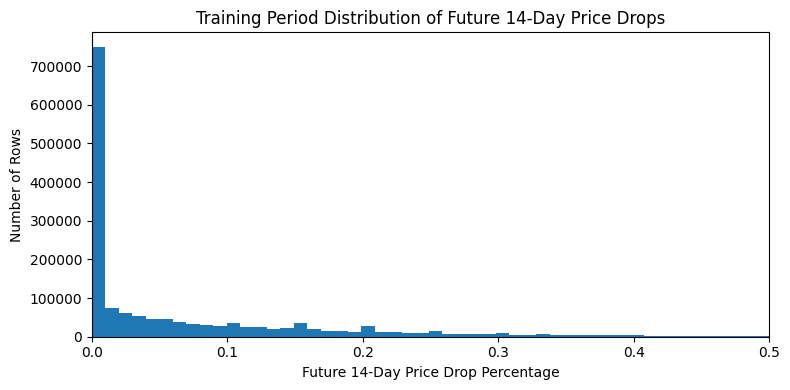

In [19]:
# Cell 5 - Inspect Future Price Drop Distribution Using Training Period Only

TRAIN_END = "2024-12-31"

train_drop_dist = df_label[df_label["date"] <= TRAIN_END]["future_drop_pct_14d"].copy()

print("Training-period rows:", len(train_drop_dist))
print("Training-period future drop percentage summary:")
display(train_drop_dist.describe(percentiles=[0.25, 0.50, 0.60, 0.70, 0.75, 0.80, 0.85, 0.90, 0.95]))

plt.figure(figsize=(8, 4))
plt.hist(train_drop_dist, bins=100)
plt.title("Training Period Distribution of Future 14-Day Price Drops")
plt.xlabel("Future 14-Day Price Drop Percentage")
plt.ylabel("Number of Rows")
plt.xlim(0, 0.5)
plt.tight_layout()
plt.show()

In [20]:
# Cell 6 - Check Candidate Price-Drop Labels Using Training Period Only

TRAIN_END = "2024-12-31"

train_label_dist = df_label[df_label["date"] <= TRAIN_END].copy()

candidate_labels = {
    "5% only": (
        train_label_dist["future_drop_pct_14d"] >= 0.05
    ),
    "5% and $5": (
        (train_label_dist["future_drop_pct_14d"] >= 0.05) &
        (train_label_dist["future_drop_abs_14d"] >= 5)
    ),
    "5% and $10": (
        (train_label_dist["future_drop_pct_14d"] >= 0.05) &
        (train_label_dist["future_drop_abs_14d"] >= 10)
    ),
    "10% only": (
        train_label_dist["future_drop_pct_14d"] >= 0.10
    )
}

label_rows = []

for label_name, label_values in candidate_labels.items():
    label_values = label_values.astype(int)
    
    label_rows.append({
        "label_definition": label_name,
        "positive_rows": label_values.sum(),
        "negative_rows": len(label_values) - label_values.sum(),
        "positive_percentage": label_values.mean() * 100,
        "negative_percentage": (1 - label_values.mean()) * 100
    })

label_summary = pd.DataFrame(label_rows)
label_summary["positive_percentage"] = label_summary["positive_percentage"].round(2)
label_summary["negative_percentage"] = label_summary["negative_percentage"].round(2)

label_summary

,label_definition,positive_rows,negative_rows,positive_percentage,negative_percentage
0,5% only,598183,986965,37.74,62.26
1,5% and $5,427902,1157246,26.99,73.01
2,5% and $10,267145,1318003,16.85,83.15
3,10% only,423911,1161237,26.74,73.26


Selected label: at least 5% drop AND at least $5 saving


,label_drop_14d,row_count,percentage
0,0,1407750,72.61
1,1,531121,27.39


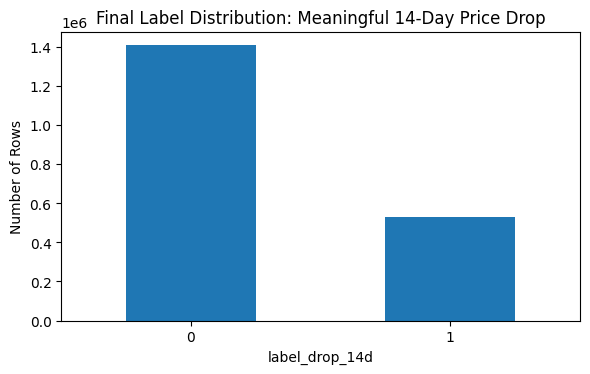

In [23]:
# Cell 7 - Create Final Meaningful 14-Day Price Drop Label

DROP_PCT_THRESHOLD = 0.05
DROP_ABS_THRESHOLD = 5.00

df_label["label_drop_14d"] = (
    (df_label["future_drop_pct_14d"] >= DROP_PCT_THRESHOLD) &
    (df_label["future_drop_abs_14d"] >= DROP_ABS_THRESHOLD)
).astype(int)

label_summary = df_label["label_drop_14d"].value_counts().reset_index()
label_summary.columns = ["label_drop_14d", "row_count"]
label_summary["percentage"] = (
    label_summary["row_count"] / len(df_label) * 100
).round(2)

print(f"Selected label: at least {DROP_PCT_THRESHOLD * 100:.0f}% drop AND at least ${DROP_ABS_THRESHOLD:.0f} saving")
display(label_summary)

plt.figure(figsize=(6, 4))
df_label["label_drop_14d"].value_counts().sort_index().plot(kind="bar")
plt.title("Final Label Distribution: Meaningful 14-Day Price Drop")
plt.xlabel("label_drop_14d")
plt.ylabel("Number of Rows")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## Label Interpretation

The final target is `label_drop_14d`.

A row is labelled as `1` if the selected modelling price drops by at least 5% and by at least $5 at any point within the next 14 days. Otherwise, it is labelled as `0`.

This combined threshold is used because a percentage-only drop can be misleading for low-priced items. For example, a 5% drop on a $20 item is only $1, which is unlikely to be meaningful for a shopper. Requiring both a relative drop and an absolute dollar saving makes the label more aligned with the target user: a deal-conscious shopper making a considered, deferrable purchase.

The percentage threshold captures proportional discount size, while the $5 absolute threshold ensures that the recommendation reflects a practical saving.

In [24]:
# Cell 9 - Create Historical Feature Set

def add_historical_features(group):
    group = group.sort_values("date").copy()

    # Price lag features
    for lag in [1, 7, 14, 30]:
        group[f"price_lag_{lag}"] = group["amazon_price"].shift(lag)

    # Price rolling features
    for window in [7, 14, 30]:
        group[f"price_rolling_mean_{window}"] = (
            group["amazon_price"].shift(1).rolling(window=window, min_periods=window).mean()
        )
        group[f"price_rolling_std_{window}"] = (
            group["amazon_price"].shift(1).rolling(window=window, min_periods=window).std()
        )

    # Price percentage change features
    for lag in [7, 14, 30]:
        group[f"price_pct_change_{lag}"] = (
            (group["amazon_price"] - group[f"price_lag_{lag}"]) / group[f"price_lag_{lag}"]
        )

    group["price_vs_rolling_mean_30"] = (
        (group["amazon_price"] - group["price_rolling_mean_30"]) / group["price_rolling_mean_30"]
    )

    # Sales rank features
    group["sales_rank_lag_7"] = group["sales_rank"].shift(7)
    group["sales_rank_rolling_mean_14"] = (
        group["sales_rank"].shift(1).rolling(window=14, min_periods=14).mean()
    )
    group["sales_rank_velocity_14"] = (
        (group["sales_rank"] - group["sales_rank"].shift(14)) / group["sales_rank"].shift(14)
    )
    group["sales_rank_missing_flag"] = group["sales_rank"].isna().astype(int)

    # Offer count features
    group["offer_count_lag_7"] = group["offer_count"].shift(7)
    group["offer_count_rolling_mean_14"] = (
        group["offer_count"].shift(1).rolling(window=14, min_periods=14).mean()
    )
    group["offer_count_trend_14"] = group["offer_count"] - group["offer_count"].shift(14)
    group["offer_count_missing_flag"] = group["offer_count"].isna().astype(int)

    # Amazon direct price missingness features
    group["amazon_price_raw_missing_rolling_14"] = (
        group["amazon_price_raw_missing"].shift(1).rolling(window=14, min_periods=14).mean()
    )

    return group


df_features = []

for asin, group in df_label.groupby("asin"):
    temp = add_historical_features(group)
    df_features.append(temp)

df_features = pd.concat(df_features, ignore_index=True)

print("Feature dataset shape before dropping feature-missing rows:", df_features.shape)
print("Unique ASINs:", df_features["asin"].nunique())

feature_preview_cols = [
    "date",
    "asin",
    "amazon_price",
    "price_lag_7",
    "price_rolling_mean_14",
    "price_pct_change_14",
    "sales_rank_lag_7",
    "offer_count_lag_7",
    "amazon_price_raw_missing_rolling_14",
    "label_drop_14d"
]

df_features[feature_preview_cols].head(20)

Feature dataset shape before dropping feature-missing rows: (1938871, 48)
Unique ASINs: 922


,date,asin,amazon_price,price_lag_7,price_rolling_mean_14,price_pct_change_14,sales_rank_lag_7,offer_count_lag_7,amazon_price_raw_missing_rolling_14,label_drop_14d
0,2021-03-12,B00002N6J9,46.50,NaN,NaN,NaN,NaN,NaN,NaN,0
1,2021-03-13,B00002N6J9,46.50,NaN,NaN,NaN,NaN,NaN,NaN,0
2,2021-03-14,B00002N6J9,47.11,NaN,NaN,NaN,NaN,NaN,NaN,0
3,2021-03-15,B00002N6J9,46.59,NaN,NaN,NaN,NaN,NaN,NaN,0
4,2021-03-16,B00002N6J9,46.78,NaN,NaN,NaN,NaN,NaN,NaN,0
5,2021-03-17,B00002N6J9,46.78,NaN,NaN,NaN,NaN,NaN,NaN,0
6,2021-03-18,B00002N6J9,46.01,NaN,NaN,NaN,NaN,NaN,NaN,0
7,2021-03-19,B00002N6J9,46.05,46.50,NaN,NaN,12.0,2.0,NaN,0
8,2021-03-20,B00002N6J9,46.05,46.50,NaN,NaN,10.0,2.0,NaN,0
9,2021-03-21,B00002N6J9,46.05,47.11,NaN,NaN,9.0,2.0,NaN,0


In [25]:
# Cell 10 - Create Calendar and Encoded Features

df_features["month"] = df_features["date"].dt.month
df_features["week_of_year"] = df_features["date"].dt.isocalendar().week.astype(int)
df_features["day_of_week"] = df_features["date"].dt.dayofweek

# Binary price source feature: 1 = AMAZON, 0 = NEW
df_features["price_source_amazon"] = (df_features["price_source"] == "AMAZON").astype(int)

df_features["price_source_changed_7d"] = (
    df_features
    .groupby("asin")["price_source_amazon"]
    .transform(lambda x: x.diff().abs().rolling(7, min_periods=1).max())
)

# One-hot encode root category
root_category_dummies = pd.get_dummies(
    df_features["root_category"],
    prefix="root_category",
    dtype=int
)

df_features = pd.concat([df_features, root_category_dummies], axis=1)

print("Feature dataset shape after calendar and encoded features:", df_features.shape)
print("Calendar features added:", ["month", "week_of_year", "day_of_week"])
print("Price source feature added:", "price_source_amazon")
print("Root category dummy columns added:")
print(list(root_category_dummies.columns))

Feature dataset shape after calendar and encoded features: (1938871, 59)
Calendar features added: ['month', 'week_of_year', 'day_of_week']
Price source feature added: price_source_amazon
Root category dummy columns added:
['root_category_Appliances', 'root_category_Electronics', 'root_category_Home & Kitchen', 'root_category_Sports & Outdoors', 'root_category_Tools & Home Improvement', 'root_category_Toys & Games']


In [26]:
# Cell 11 - Add Retail Event Calendar Features

def get_black_friday(year):
    """
    Black Friday is the day after US Thanksgiving.
    US Thanksgiving is the 4th Thursday of November.
    """
    november = pd.date_range(f"{year}-11-01", f"{year}-11-30", freq="D")
    thursdays = november[november.dayofweek == 3]
    thanksgiving = thursdays[3]
    return thanksgiving + pd.Timedelta(days=1)


def get_cyber_monday(year):
    """
    Cyber Monday is the Monday after Black Friday.
    """
    return get_black_friday(year) + pd.Timedelta(days=3)


# Create a unique calendar table instead of applying row-by-row to 1.9M rows
calendar_df = pd.DataFrame({
    "date": pd.date_range(df_features["date"].min(), df_features["date"].max(), freq="D")
})

calendar_df["year"] = calendar_df["date"].dt.year

event_years = range(calendar_df["year"].min(), calendar_df["year"].max() + 2)

black_friday_dates = pd.Series(
    {year: get_black_friday(year) for year in event_years}
)

cyber_monday_dates = pd.Series(
    {year: get_cyber_monday(year) for year in event_years}
)

christmas_dates = pd.Series(
    {year: pd.Timestamp(f"{year}-12-25") for year in event_years}
)


def add_days_until_event(calendar_df, event_dates, output_col):
    current_event = calendar_df["year"].map(event_dates)
    next_event = (calendar_df["year"] + 1).map(event_dates)

    days = (current_event.values - calendar_df["date"].values).astype("timedelta64[D]").astype(int)
    next_days = (next_event.values - calendar_df["date"].values).astype("timedelta64[D]").astype(int)

    calendar_df[output_col] = np.where(days >= 0, days, next_days)

    return calendar_df


calendar_df = add_days_until_event(calendar_df, black_friday_dates, "days_until_black_friday")
calendar_df = add_days_until_event(calendar_df, cyber_monday_dates, "days_until_cyber_monday")
calendar_df = add_days_until_event(calendar_df, christmas_dates, "days_until_christmas")

calendar_df["is_black_friday_period"] = (
    calendar_df["days_until_black_friday"] <= 14
).astype(int)

calendar_df["is_cyber_monday_period"] = (
    calendar_df["days_until_cyber_monday"] <= 14
).astype(int)

calendar_df["is_christmas_period"] = (
    calendar_df["days_until_christmas"] <= 30
).astype(int)

event_cols = [
    "date",
    "days_until_black_friday",
    "days_until_cyber_monday",
    "days_until_christmas",
    "is_black_friday_period",
    "is_cyber_monday_period",
    "is_christmas_period"
]

df_features = df_features.merge(calendar_df[event_cols], on="date", how="left")

event_summary = pd.DataFrame({
    "feature": [
        "days_until_black_friday",
        "days_until_cyber_monday",
        "days_until_christmas",
        "is_black_friday_period",
        "is_cyber_monday_period",
        "is_christmas_period"
    ],
    "meaning": [
        "Days remaining until the next Black Friday",
        "Days remaining until the next Cyber Monday",
        "Days remaining until the next Christmas Day",
        "1 if the date is within 14 days before Black Friday",
        "1 if the date is within 14 days before Cyber Monday",
        "1 if the date is within 30 days before Christmas"
    ],
    "min": [
        df_features["days_until_black_friday"].min(),
        df_features["days_until_cyber_monday"].min(),
        df_features["days_until_christmas"].min(),
        df_features["is_black_friday_period"].min(),
        df_features["is_cyber_monday_period"].min(),
        df_features["is_christmas_period"].min()
    ],
    "max": [
        df_features["days_until_black_friday"].max(),
        df_features["days_until_cyber_monday"].max(),
        df_features["days_until_christmas"].max(),
        df_features["is_black_friday_period"].max(),
        df_features["is_cyber_monday_period"].max(),
        df_features["is_christmas_period"].max()
    ]
})

event_summary

,feature,meaning,min,max
0,days_until_black_friday,Days remaining until the next Black Friday,0,370
1,days_until_cyber_monday,Days remaining until the next Cyber Monday,0,370
2,days_until_christmas,Days remaining until the next Christmas Day,0,365
3,is_black_friday_period,1 if the date is within 14 days before Black Friday,0,1
4,is_cyber_monday_period,1 if the date is within 14 days before Cyber Monday,0,1
5,is_christmas_period,1 if the date is within 30 days before Christmas,0,1


In [27]:
# Cell 12 - Check Missingness in Final Candidate Model Features

target_cols = [
    "future_min_price_14d",
    "future_window_days_14d",
    "future_drop_pct_14d",
    "future_drop_abs_14d",
    "label_drop_14d"
]

reference_cols = [
    "date",
    "asin",
    "title",
    "brand",
    "manufacturer",
    "leaf_category",
    "price_source",
    "availability_amazon_label",
    "amazon_price_raw",
    "new_price_raw",
    "availability_amazon",
    "availability_delay_min_hours",
    "availability_delay_max_hours"
]

excluded_cols = target_cols + reference_cols

candidate_feature_cols = [
    col for col in df_features.columns
    if col not in excluded_cols
]

missing_summary = (
    df_features[candidate_feature_cols]
    .isna()
    .mean()
    .mul(100)
    .round(2)
    .sort_values(ascending=False)
    .reset_index()
)

missing_summary.columns = ["feature", "missing_percentage"]

print("Number of candidate model feature columns:", len(candidate_feature_cols))
print("Rows before final feature filtering:", len(df_features))

missing_summary.head(20)

Number of candidate model feature columns: 47
Rows before final feature filtering: 1938871


,feature,missing_percentage
0,offer_count_rolling_mean_14,49.82
1,offer_count_trend_14,40.91
2,offer_count_lag_7,31.24
3,offer_count,31.06
4,sales_rank_rolling_mean_14,6.97
5,sales_rank_velocity_14,6.65
6,sales_rank_lag_7,5.97
7,sales_rank,5.64
8,price_rolling_std_30,1.43
9,price_rolling_mean_30,1.43


In [28]:
# Cell 13 - Create Final Modelling Dataset

core_required_features = [
    "price_lag_30",
    "price_rolling_mean_30",
    "price_rolling_std_30",
    "price_pct_change_30",
    "price_vs_rolling_mean_30",
    "amazon_price_raw_missing_rolling_14"
]

rows_before = len(df_features)

model_df = df_features.dropna(subset=core_required_features + ["label_drop_14d"]).copy()

rows_after = len(model_df)

print("Rows before final filtering:", rows_before)
print("Rows after final filtering:", rows_after)
print("Rows dropped:", rows_before - rows_after)
print("Percentage dropped:", round((rows_before - rows_after) / rows_before * 100, 2))
print("Unique ASINs after filtering:", model_df["asin"].nunique())

label_check = model_df["label_drop_14d"].value_counts(normalize=True).mul(100).round(2)
print("\nFinal label distribution (%):")
print(label_check)

Rows before final filtering: 1938871
Rows after final filtering: 1911211
Rows dropped: 27660
Percentage dropped: 1.43
Unique ASINs after filtering: 922

Final label distribution (%):
label_drop_14d
0    72.55
1    27.45
Name: proportion, dtype: float64


In [29]:
# Cell 14 - Create Time-Based Train, Validation, and Test Splits

train_mask = model_df["date"] <= "2024-12-31"
val_mask = (model_df["date"] >= "2025-01-01") & (model_df["date"] <= "2025-12-31")
test_mask = model_df["date"] >= "2026-01-01"

split_summary = pd.DataFrame({
    "split": ["train", "validation", "test"],
    "start_date": [
        model_df.loc[train_mask, "date"].min().date(),
        model_df.loc[val_mask, "date"].min().date(),
        model_df.loc[test_mask, "date"].min().date()
    ],
    "end_date": [
        model_df.loc[train_mask, "date"].max().date(),
        model_df.loc[val_mask, "date"].max().date(),
        model_df.loc[test_mask, "date"].max().date()
    ],
    "rows": [
        train_mask.sum(),
        val_mask.sum(),
        test_mask.sum()
    ],
    "unique_asins": [
        model_df.loc[train_mask, "asin"].nunique(),
        model_df.loc[val_mask, "asin"].nunique(),
        model_df.loc[test_mask, "asin"].nunique()
    ],
    "positive_label_percentage": [
        model_df.loc[train_mask, "label_drop_14d"].mean() * 100,
        model_df.loc[val_mask, "label_drop_14d"].mean() * 100,
        model_df.loc[test_mask, "label_drop_14d"].mean() * 100
    ]
})

split_summary["positive_label_percentage"] = split_summary["positive_label_percentage"].round(2)

split_summary

,split,start_date,end_date,rows,unique_asins,positive_label_percentage
0,train,2015-01-31,2024-12-31,1557488,922,27.06
1,validation,2025-01-01,2025-12-31,255671,922,28.89
2,test,2026-01-01,2026-05-18,98052,922,29.95


In [30]:
# Cell 15 - Add Split Column and Save Final Feature Dataset

model_df["split"] = np.select(
    [
        model_df["date"] <= "2024-12-31",
        (model_df["date"] >= "2025-01-01") & (model_df["date"] <= "2025-12-31"),
        model_df["date"] >= "2026-01-01"
    ],
    [
        "train",
        "validation",
        "test"
    ],
    default="unused"
)

model_df.to_csv(FEATURES_PATH, index=False)

print("Saved feature dataset to:", FEATURES_PATH)
print("Final feature dataset shape:", model_df.shape)

print("\nSplit distribution:")
print(model_df["split"].value_counts())

print("\nFinal label distribution by split:")
display(
    model_df.groupby("split")["label_drop_14d"]
    .agg(["count", "mean"])
    .rename(columns={"count": "rows", "mean": "positive_rate"})
)

Saved feature dataset to: ../data/processed/features_v2.csv
Final feature dataset shape: (1911211, 66)

Split distribution:
split
train         1557488
validation     255671
test            98052
Name: count, dtype: int64

Final label distribution by split:


,rows,positive_rate
split,,
test,98052,0.299453
train,1557488,0.270569
validation,255671,0.288875


## Feature Engineering Summary

This notebook creates the final modelling dataset for the 14-day price-drop prediction model.

Each row represents one product on one prediction date. All engineered features are based only on information available up to that date. The target label looks forward 14 days to determine whether a meaningful price drop occurs.

### Target label

The target variable is: `label_drop_14d`

A row is labelled as `1` if the selected modelling price drops by at least 5% at any point from `T+1` to `T+14`.

The label is created using:
- `future_min_price_14d`: the lowest selected price in the next 14 days
- `future_drop_pct_14d`: the percentage drop from the current price to that future minimum
- `label_drop_14d`: binary label using a 5% drop threshold

The 5% threshold was chosen after inspecting the future price-drop distribution in the training period only. This avoids using validation or test information when deciding the label threshold.

### Price-history features

Price features are created from `amazon_price`, which represents the selected modelling price. It uses Amazon direct price when available, otherwise the lowest new-offer price.

The engineered price features include:
- price lags over 1, 7, 14, and 30 days
- rolling price means over 7, 14, and 30 days
- rolling price standard deviations over 7, 14, and 30 days
- percentage price changes over 7, 14, and 30 days
- current price relative to the 30-day rolling average

These features allow the model to learn whether the current price is unusually high, unusually low, stable, or volatile.

### Sales-rank features

Sales-rank features are created from the historical `sales_rank` series.

The engineered sales-rank features include:
- `sales_rank_lag_7`
- `sales_rank_rolling_mean_14`
- `sales_rank_velocity_14`
- `sales_rank_missing_flag`

These features capture product demand and recent demand movement. Lower sales rank generally indicates stronger product popularity.

### Offer-count features

Offer-count features are created from `offer_count`, which represents the number of new offers available.

The engineered offer-count features include:
- `offer_count_lag_7`
- `offer_count_rolling_mean_14`
- `offer_count_trend_14`
- `offer_count_missing_flag`

These features are used as supporting signals for marketplace competition and availability. Offer-count features contain more missing values than the core price features, so they are retained but not treated as mandatory filtering features.

### Price-source and missingness features

The model keeps information about where the selected price came from:
- `price_source_amazon`: 1 if the selected price came from Amazon direct price history, 0 if it came from the lowest new-offer price history
- `new_price_shipping_included`: flags NEW-price rows after February 16, 2026, when Keepa's NEW price field may include shipping costs
- `amazon_price_raw_missing_rolling_14`: recent frequency of missing Amazon direct price observations

These features help the model distinguish Amazon-direct price behaviour from broader new-offer marketplace behaviour.

### Calendar and retail-event features

Calendar features are created from the prediction date:
- `month`
- `week_of_year`
- `day_of_week`

Retail-event features are also added for major US shopping periods:
- `days_until_black_friday`
- `days_until_cyber_monday`
- `days_until_christmas`
- `is_black_friday_period`
- `is_cyber_monday_period`
- `is_christmas_period`

Black Friday is calculated as the day after US Thanksgiving, where Thanksgiving is the fourth Thursday of November. Cyber Monday is calculated as the Monday after Black Friday. Christmas is fixed on December 25.

### Category features

The `root_category` field is one-hot encoded because the cleaned dataset contains six main product categories. Root category is used instead of raw leaf category because the raw exploration showed that leaf categories were highly sparse.

### Final filtering

Rows are dropped only if they are missing core price-history features required for reliable modelling. Rows are not dropped solely because offer-count features are missing, because offer-count is a supporting signal and XGBoost can handle missing values.

The final split is chronological:
- training: dates up to 2024-12-31
- validation: 2025-01-01 to 2025-12-31
- test: 2026-01-01 onward, ending where a full 14-day future label is still available

The training split begins on 2015-01-31 because 30-day lag and rolling features require at least 30 previous days of history.

This split reflects the intended real-world use case: training on historical data and predicting future price drops.